# 02 — Results

1. **Overview** — every tested model side by side (grows as models are added)
2. **Input ladder** — which input to give the model (ridge): window design, feature groups, what each input fixes
3. **Model ladder** — which model on the chosen input (kernel ridge so far; SVM, trees to come)
4. **Model cards** — one per tested model: validation curve, confusion matrices, scores, interpretation

Every model is trained with `python -m src.train <model> <input>`, which writes `outputs/results/<name>.json`
(test scores + validation curve) and the test predictions. Choices between inputs were made with `--val-only`
(validation scores in `outputs/results/validation/`, test never used).

Setup (see `PROGRESS.md`): protocol A split, train/val stride 10, test on every timestep.
4 binary problems (one per leg), contact = positive class. Metrics computed per leg and averaged.

## 0. Setup

In [92]:
# plot settings
VAL_PLOT_3D = False   # model cards: True = 3-D surface for two-hyperparameter grids, False = annotated 2-D heatmap

In [93]:
import sys; sys.path.insert(0, "..")
import json
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import joblib
from sklearn.metrics import confusion_matrix, f1_score
from src.data import LEGS, labels, load_recordings, split
from src.features import LAGS

RESULTS = Path("../outputs/results")
runs = {p.stem: json.loads(p.read_text()) for p in sorted(RESULTS.glob("*.json"), key=lambda p: p.stat().st_mtime)}
val_runs = {p.stem: json.loads(p.read_text()) for p in sorted((RESULTS / "validation").glob("*.json"))}
recs = load_recordings()
test_ends = split(recs)["test"]
y_test = labels(recs, test_ends)
preds = {name: np.load(RESULTS / f"{name}_test_pred.npy") for name in runs}
models = [name for name in runs if name != "majority"]

# channel names, in input order
CHANNELS = ([f"q {leg} {j}" for leg in LEGS for j in ("abad", "hip", "knee")]
            + [f"qd {leg} {j}" for leg in LEGS for j in ("abad", "hip", "knee")]
            + [f"acc {a}" for a in "xyz"] + [f"omega {a}" for a in "xyz"]
            + [f"p {leg} {a}" for leg in LEGS for a in "xyz"] + [f"v {leg} {a}" for leg in LEGS for a in "xyz"])
list(runs)

['majority',
 'ridge_current',
 'ridge_window_log',
 'ridge_feat_all',
 'ridge_10k_feat_all',
 'krr_feat_all']

In [94]:
def best_val(name):
    """Best validation F1 of a run (tested or validation-only)."""
    v = runs[name]["validation"] if name in runs else val_runs[name]
    return max(r["val_f1"] for r in v)

def per_recording(p):
    """Test F1 per ground recording; false-contact rate for the air recordings (no contacts to find)."""
    out, i = {}, 0
    for name, e in test_ends.items():
        y, q = y_test[i:i + len(e)], p[i:i + len(e)]
        i += len(e)
        out[name] = (np.mean([f1_score(y[:, k], q[:, k], zero_division=0) for k in range(4)])
                     if y.any() else q.mean())
    return pd.Series(out)

def error_rates(p):
    return {"false-contact rate": ((p == 1) & (y_test == 0)).sum() / (y_test == 0).sum(),
            "missed-contact rate": ((p == 0) & (y_test == 1)).sum() / (y_test == 1).sum()}

def model_card(name):
    """Validation curve (if tuned), per-leg confusion matrices (% of the true class) and test scores."""
    val = runs[name]["validation"]
    params = list(val[0]["params"]) if len(val) > 1 else []
    short = lambda p: p.split("__")[-1]
    if len(params) == 1:  # one hyperparameter on a log grid -> curve
        (param,) = params
        x, f = [v["params"][param] for v in val], [v["val_f1"] for v in val]
        b = int(np.argmax(f))
        plt.figure(figsize=(6, 2.5))
        plt.semilogx(x, f, "o-")
        plt.semilogx(x[b], f[b], "o", color="red", ms=9, label=f"chosen: {short(param)} = {x[b]:g}, F1 {f[b]:.4f}")
        plt.xlabel(short(param)); plt.ylabel("validation F1"); plt.title(f"{name} — validation curve")
        plt.legend(fontsize=8, loc="lower left"); plt.tight_layout(); plt.show()
    elif len(params) == 2:  # two hyperparameters -> 2-D heatmap or 3-D surface of validation F1
        grid = pd.DataFrame([{short(k): v["params"][k] for k in params} | {"F1": v["val_f1"]} for v in val])
        grid = grid.pivot(index=short(params[0]), columns=short(params[1]), values="F1")
        F, (i_best, j_best) = grid.values, np.unravel_index(np.argmax(grid.values), grid.shape)
        if VAL_PLOT_3D:
            gx, gy = np.meshgrid(np.log10(grid.columns.astype(float)), np.log10(grid.index.astype(float)))
            fig = plt.figure(figsize=(10, 6.5))
            ax = fig.add_subplot(projection="3d", computed_zorder=False)  # draw markers on top of the surface
            ax.plot_surface(gx, gy, F, cmap="viridis", alpha=0.8, edgecolor="grey", linewidth=0.3, zorder=1)
            ax.scatter(gx, gy, F, color="k", s=10, zorder=2, depthshade=False)
            ax.scatter(gx[i_best, j_best], gy[i_best, j_best], F[i_best, j_best], color="red", s=80, zorder=3,
                       depthshade=False)
            ax.text(gx[i_best, j_best], gy[i_best, j_best], F[i_best, j_best] + 0.003,
                    f"chosen {F[i_best, j_best]:.4f}", color="red", zorder=4,
                    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"))
            ax.set_xlabel(f"log10 {grid.columns.name}"); ax.set_ylabel(f"log10 {grid.index.name}")
            ax.set_zlabel("validation F1", labelpad=12); ax.set_title(f"{name} — validation F1")
            ax.view_init(elev=28, azim=-50)
            ax.set_box_aspect(None, zoom=0.85)  # leave room for the axis labels
        else:
            fig, ax = plt.subplots(figsize=(1.4 * grid.shape[1] + 2, 0.8 * grid.shape[0] + 1.5))
            ax.imshow(F, cmap="viridis", aspect="auto")
            for i in range(grid.shape[0]):
                for j in range(grid.shape[1]):
                    ax.text(j, i, f"{F[i, j]:.4f}", ha="center", va="center", fontsize=10,
                            color="black" if F[i, j] > F.mean() else "white",
                            fontweight="bold" if (i, j) == (i_best, j_best) else "normal")
            ax.add_patch(plt.Rectangle((j_best - 0.5, i_best - 0.5), 1, 1, fill=False, color="red", lw=2))
            ax.set_xticks(range(grid.shape[1]), grid.columns); ax.set_yticks(range(grid.shape[0]), grid.index)
            ax.set_xlabel(grid.columns.name); ax.set_ylabel(grid.index.name)
            ax.set_title(f"{name} — validation F1 (red: chosen)")
        plt.tight_layout(); plt.show()
    p, t = preds[name], runs[name]["test"]
    fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
    for k, (ax, leg) in enumerate(zip(axes, LEGS)):
        cm = confusion_matrix(y_test[:, k], p[:, k], labels=[0, 1])
        pct = 100 * cm / cm.sum(1, keepdims=True)
        ax.imshow(pct, cmap="Blues", vmin=0, vmax=100)
        for i in range(2):
            for j in range(2):
                ax.text(j, i, f"{pct[i, j]:.1f}%\n({cm[i, j]:,})", ha="center", va="center",
                        color="white" if pct[i, j] > 60 else "black")
        ax.set_xticks([0, 1], ["air", "contact"]); ax.set_yticks([0, 1], ["air", "contact"])
        ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title(f"{name} — {leg}")
    plt.tight_layout(); plt.show()
    table = pd.DataFrame({**{leg: t["per_leg"][leg] for leg in LEGS},
                          "mean": {m: t[m] for m in ("f1", "precision", "recall", "accuracy")}}).T
    display(table.round(4))
    print(f"exact-state accuracy (all 4 legs right): {t['exact']:.4f}")

## 1. Overview — all tested models

Confusion-matrix percentages (section 4) are per **true** class: each row sums to 100%. Bottom-right = recall on
contact; top-right = false-contact rate (air timesteps called contact) — the error that hurts the EKF.

In [95]:
summary = pd.DataFrame({
    name: {"F1": r["test"]["f1"], "precision": r["test"]["precision"], "recall": r["test"]["recall"],
           "accuracy": r["test"]["accuracy"], "exact-state": r["test"]["exact"],
           **error_rates(preds[name]),
           "F1 (every 10th)": r["test_stride10"]["f1"], "exact-state (every 10th)": r["test_stride10"]["exact"]}
    for name, r in runs.items()}).T
summary.round(4)

,F1,precision,recall,accuracy,exact-state,false-contact rate,missed-contact rate,F1 (every 10th),exact-state (every 10th)
majority,0.0000,0.0000,0.0000,0.6648,0.3679,0.0000,1.0000,0.0000,0.3685
ridge_current,0.8404,0.8720,0.8112,0.8967,0.7992,0.0601,0.1888,0.8418,0.8012
ridge_window_log,0.9297,0.9344,0.9251,0.9532,0.8789,0.0327,0.0749,0.9312,0.8824
ridge_feat_all,0.9463,0.9383,0.9545,0.9637,0.8987,0.0317,0.0455,0.9475,0.9009
ridge_10k_feat_all,0.9421,0.9356,0.9487,0.9609,0.8905,0.0330,0.0513,0.9435,0.8933
krr_feat_all,0.9558,0.9511,0.9604,0.9702,0.9091,0.0249,0.0395,0.9558,0.9095


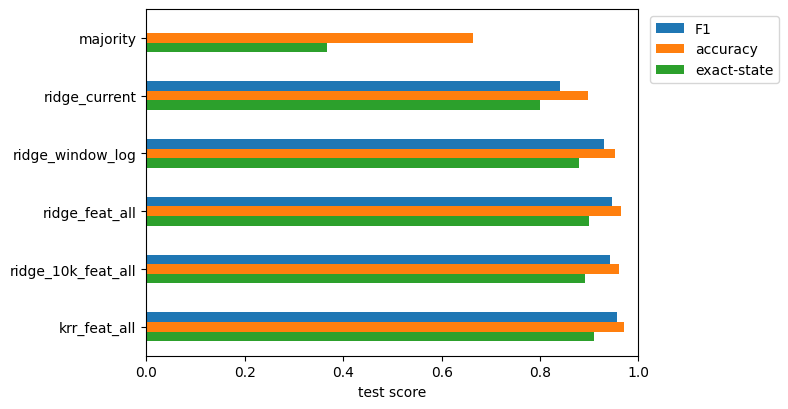

In [96]:
ax = summary[["F1", "accuracy", "exact-state"]].plot.barh(figsize=(8, 0.6 + 0.6 * len(summary)))
ax.set_xlim(0, 1); ax.invert_yaxis(); ax.set_xlabel("test score")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1))  # outside the axes, so it never covers bars
plt.tight_layout()

### Per leg (test F1)

In [97]:
pd.DataFrame({name: {leg: r["test"]["per_leg"][leg]["f1"] for leg in LEGS} for name, r in runs.items()}).T.round(4)

,RF,LF,RH,LH
majority,0.0000,0.0000,0.0000,0.0000
ridge_current,0.8413,0.8317,0.8441,0.8446
ridge_window_log,0.9350,0.9135,0.9282,0.9423
ridge_feat_all,0.9474,0.9354,0.9465,0.9558
ridge_10k_feat_all,0.9429,0.9316,0.9418,0.9519
krr_feat_all,0.9542,0.9500,0.9574,0.9614


### Per recording (test F1; for the air recordings: false-contact rate)

In [98]:
by_rec = pd.DataFrame({name: per_recording(preds[name]) for name in models})
by_rec.round(3)

,ridge_current,ridge_window_log,ridge_feat_all,ridge_10k_feat_all,krr_feat_all
air_jumping_gait,0.014,0.000,0.000,0.000,0.000
air_walking_gait,0.004,0.000,0.000,0.000,0.000
asphalt_road,0.935,0.966,0.963,0.965,0.973
old_asphalt_road,0.850,0.914,0.913,0.910,0.929
concrete_difficult_slippery,0.879,0.950,0.959,0.954,0.964
concrete_galloping,0.583,0.781,0.832,0.818,0.868
concrete_left_circle,0.911,0.964,0.965,0.965,0.974
concrete_pronking,0.608,0.906,0.958,0.953,0.971
concrete_right_circle,0.876,0.956,0.960,0.956,0.966
forest,0.902,0.944,0.941,0.937,0.947


## 2. Input ladder (ridge)

Same model (ridge), same split; only the input changes. Choices inside each step were made on **validation**;
only the chosen input of each step was tested.

### 2.1 Window design — which past timesteps?

All variants: 15 lags × 54 channels = 810 values, spanning 15, 30 or 150 ms (150 ms = the dataset paper's
convention). Validation only.

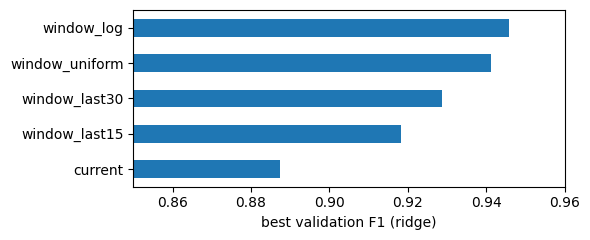

,lags (ms before the label)
window_uniform,"[np.int64(0), np.int64(10), np.int64(20), np.i..."
window_log,"[np.int64(0), np.int64(1), np.int64(2), np.int..."
window_last15,"[np.int64(0), np.int64(1), np.int64(2), np.int..."
window_last30,"[np.int64(0), np.int64(2), np.int64(4), np.int..."


In [99]:
windows = ["ridge_current"] + [f"ridge_{n}" for n in LAGS if f"ridge_{n}" in val_runs or f"ridge_{n}" in runs]
val_win = pd.Series({n.removeprefix("ridge_"): best_val(n) for n in windows}).sort_values()
val_win.plot.barh(figsize=(6, 2.5), xlim=(0.85, 0.96)); plt.xlabel("best validation F1 (ridge)"); plt.tight_layout(); plt.show()
pd.DataFrame({"lags (ms before the label)": {n: str(list(LAGS[n])) for n in LAGS if n in val_win}})

- **Longer context matters**: last 15 ms < last 30 ms < 150 ms — the gait phase is invisible in short windows.
- **Recent detail matters**: same size and span, dense-recent (log) beats uniform 10 ms spacing — plain
  subsampling drops the last milliseconds, where touchdown shows up first.

→ `window_log` chosen.

### 2.2 Feature groups — which hand-crafted features?

Features over the 150 ms window (`src/features.py`), each with a reason:
- **g1, linear summaries** (216): current value, change over the last 5 ms and 50 ms, window mean — per channel;
- **g2 stats** (162): window std, min, max — per channel (activity level, extremes of the stride);
- **g2 foot** (12): per foot, height above its window minimum ("at its lowest" = the label's definition),
  speed ‖v‖ now and over the last 20 ms ("foot stationary" — the non-linear fix for `v_z ≈ 0`).

For ridge, linear summaries add little (it can already form weighted sums of lags); the non-linear ones
are new information. Validation only.

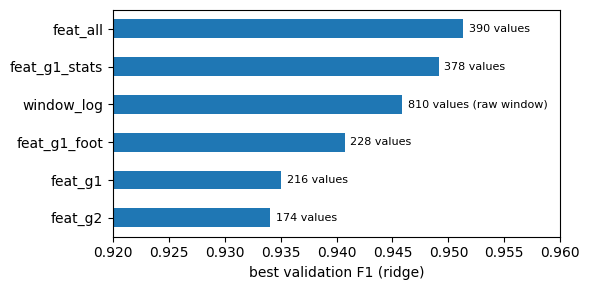

In [100]:
sizes = {"feat_g1": 216, "feat_g2": 174, "feat_g1_foot": 228, "feat_g1_stats": 378, "feat_all": 390, "window_log": 810}
val_feat = pd.Series({n: best_val(f"ridge_{n}") for n in sizes}).sort_values()
ax = val_feat.plot.barh(figsize=(6, 3), xlim=(0.92, 0.96)); ax.set_xlabel("best validation F1 (ridge)")
for i, n in enumerate(val_feat.index):
    ax.text(val_feat[n] + 0.0005, i, f"{sizes[n]} values" + (" (raw window)" if n == "window_log" else ""),
            va="center", fontsize=8)
plt.tight_layout()

- Each group alone is ~1 point **below** the raw window; together (+1.6 over either) they beat it with half the values.
- Generic stats give most of the gain; the 12 foot features are ~5× more efficient per value. On top of the
  stats they add only +0.2: "height above minimum" = current − min is already formable by ridge from g1 + stats;
  the rest comes from foot speed.

→ `feat_all` chosen.

### 2.3 What each input fixes (test)

The chosen input of each step, tested once: nothing → current timestep → raw window → features.

In [101]:
ladder = ["majority", "ridge_current", "ridge_window_log", "ridge_feat_all"]
summary.loc[ladder, ["F1", "precision", "recall", "exact-state", "false-contact rate", "missed-contact rate"]].round(4)

,F1,precision,recall,exact-state,false-contact rate,missed-contact rate
majority,0.0000,0.0000,0.0000,0.3679,0.0000,1.0000
ridge_current,0.8404,0.8720,0.8112,0.7992,0.0601,0.1888
ridge_window_log,0.9297,0.9344,0.9251,0.8789,0.0327,0.0749
ridge_feat_all,0.9463,0.9383,0.9545,0.8987,0.0317,0.0455


In [102]:
steps = by_rec[ladder[1:]].copy()
steps["history gain"] = steps["ridge_window_log"] - steps["ridge_current"]
steps["features gain"] = steps["ridge_feat_all"] - steps["ridge_window_log"]
steps.round(3)

,ridge_current,ridge_window_log,ridge_feat_all,history gain,features gain
air_jumping_gait,0.014,0.000,0.000,-0.014,-0.000
air_walking_gait,0.004,0.000,0.000,-0.004,-0.000
asphalt_road,0.935,0.966,0.963,0.032,-0.003
old_asphalt_road,0.850,0.914,0.913,0.064,-0.001
concrete_difficult_slippery,0.879,0.950,0.959,0.071,0.009
concrete_galloping,0.583,0.781,0.832,0.198,0.051
concrete_left_circle,0.911,0.964,0.965,0.053,0.001
concrete_pronking,0.608,0.906,0.958,0.299,0.052
concrete_right_circle,0.876,0.956,0.960,0.079,0.004
forest,0.902,0.944,0.941,0.042,-0.003


(Air recordings: values are false-contact rates, so there a **negative** gain is an improvement.)

- **0 → 0.840 → 0.930 → 0.946**: baseline → one instant → raw history → features.
- **History (+9 points)** fixes exactly where one instant fails: pronking 0.61 → 0.91, galloping 0.58 → 0.78;
  false contacts in the air recordings drop to 0.
- **Features (+1.7)** gain on the same non-trot gaits again (pronking → 0.96, galloping → 0.83) and grass; trot
  terrains, already ~0.95–0.97, barely move. The whole gain is *found* contacts: missed contacts 7.5% → 4.6%,
  false contacts stay ~3.2% — recall now exceeds precision only because recall rose, not riskier for the EKF.
- **Validation → test gap**: 4.7 (current) → 1.6 (window) → 0.5 points (features): window information makes the
  model less sensitive to the gait drift within a recording.
- α is flat for every input: still a linear model limited by its boundary → the model ladder (section 3).

## 3. Model ladder (on `feat_all`)

Same input (`feat_all`), same split; only the model changes. *To come:* SVM (hinge loss), trees.

**Kernel methods are trained on 10k windows**, taken evenly in time from the training block: they work on
pairs of training samples (kernel ridge stores an n × n matrix — 70k windows would need 40 GB, and its solve
costs ~n³). To keep the comparison fair, **ridge is also trained on the same 10k windows** (`ridge_10k`):
- ridge (70k) vs ridge_10k → what the subsample costs;
- ridge_10k vs kernel ridge → what the non-linear boundary adds, on identical data.
All models are still tested on every test timestep.

In [103]:
ladder_m = ["ridge_feat_all", "ridge_10k_feat_all", "krr_feat_all"]
summary.loc[ladder_m, ["F1", "precision", "recall", "exact-state", "false-contact rate", "missed-contact rate"]].round(4)

,F1,precision,recall,exact-state,false-contact rate,missed-contact rate
ridge_feat_all,0.9463,0.9383,0.9545,0.8987,0.0317,0.0455
ridge_10k_feat_all,0.9421,0.9356,0.9487,0.8905,0.0330,0.0513
krr_feat_all,0.9558,0.9511,0.9604,0.9091,0.0249,0.0395


In [104]:
steps_m = by_rec[ladder_m].copy()
steps_m["subsample cost"] = steps_m["ridge_10k_feat_all"] - steps_m["ridge_feat_all"]
steps_m["kernel gain"] = steps_m["krr_feat_all"] - steps_m["ridge_10k_feat_all"]
steps_m.round(3)

,ridge_feat_all,ridge_10k_feat_all,krr_feat_all,subsample cost,kernel gain
air_jumping_gait,0.000,0.000,0.000,0.000,-0.000
air_walking_gait,0.000,0.000,0.000,0.000,0.000
asphalt_road,0.963,0.965,0.973,0.002,0.007
old_asphalt_road,0.913,0.910,0.929,-0.004,0.019
concrete_difficult_slippery,0.959,0.954,0.964,-0.005,0.010
concrete_galloping,0.832,0.818,0.868,-0.014,0.050
concrete_left_circle,0.965,0.965,0.974,0.001,0.009
concrete_pronking,0.958,0.953,0.971,-0.005,0.018
concrete_right_circle,0.960,0.956,0.966,-0.004,0.010
forest,0.941,0.937,0.947,-0.004,0.010


- **The subsample costs ridge little**: test 0.946 → 0.942 (validation identical, 0.951); with 390 weights
  10k windows are nearly enough.
- **The RBF kernel adds +1.4 points on identical data** (0.942 → 0.956), and +1.0 over ridge on all 70k windows —
  even with 7× fewer training windows. The non-linear boundary helps on top of the features.
- **It reduces both kinds of error**: false contacts 3.3% → 2.5%, missed contacts 5.1% → 4.0%.
- **Gains on every ground recording**, largest on the hardest: galloping 0.818 → 0.868, pronking, small pebble,
  old asphalt (+0.02). Grass and rock road barely move.
- Validation → test gap 0.7 points (0.963 → 0.956).

## 4. Model cards

### 4.1 Majority baseline

Ignores the input and predicts each leg's most frequent training label. For every leg that is
"no contact", so the model always says *all four feet in the air*.

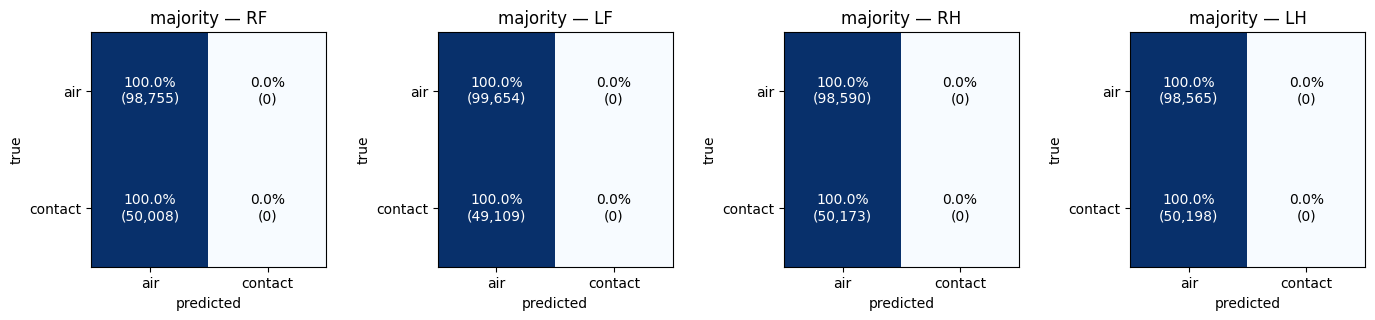

,f1,precision,recall,accuracy
RF,0.0,0.0,0.0,0.6638
LF,0.0,0.0,0.0,0.6699
RH,0.0,0.0,0.0,0.6627
LH,0.0,0.0,0.0,0.6626
mean,0.0,0.0,0.0,0.6648


exact-state accuracy (all 4 legs right): 0.3679


In [105]:
model_card("majority")

Every contact is missed (bottom row) and nothing is ever predicted as contact (right column is empty):
- **precision** = TP / (TP + FP) = 0/0 → reported as 0, **recall** = TP / (TP + FN) = 0, so **F1 = 0**;
- **accuracy** = (TP + TN) / all ≈ 0.665 — two thirds "right" with no information at all.

That is why F1 on the contact class is the main metric: a model only scores if it actually finds contacts.

In [106]:
print("share of test timesteps with all four feet in the air:", np.mean(y_test.sum(1) == 0).round(4))

share of test timesteps with all four feet in the air: 0.3679


Exact-state accuracy 0.368 is just how often *all* feet are in the air in the test blocks (air recordings
and the flight phases of the trot) — the zero point every model must clearly beat.

### 4.2 Ridge — current timestep (54 inputs)

Standardized inputs → `RidgeClassifier` (least squares on ±1 targets + α‖w‖², contact if score > 0),
one fit for the 4 legs. α chosen on validation (train-only fit), then refit on train+val.

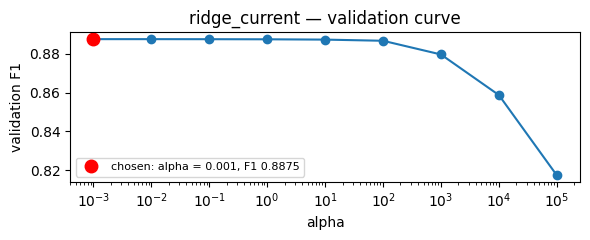

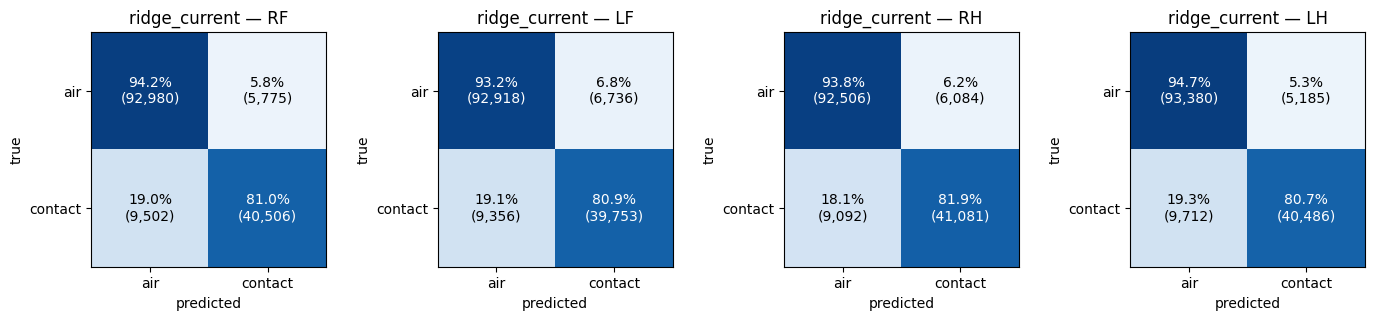

,f1,precision,recall,accuracy
RF,0.8413,0.8752,0.8100,0.8973
LF,0.8317,0.8551,0.8095,0.8918
RH,0.8441,0.8710,0.8188,0.8980
LH,0.8446,0.8865,0.8065,0.8999
mean,0.8404,0.8720,0.8112,0.8967


exact-state accuracy (all 4 legs right): 0.7992


In [107]:
model_card("ridge_current")

- **Validation curve flat** for every α up to 10, falling only when the penalty squashes the weights. The best α
  is on the grid's lower edge, but the curve is already flat there (ridge → ordinary least squares). With ~85k
  samples and 54 weights there is nothing to over-fit: the model **under-fits** — the limit is the linear
  boundary, not the tuning (same conclusion as the EMG project).
- Precision 0.87 > recall 0.81: errors are mostly **missed contacts**, the safe side for the EKF. Least squares
  on a 32/68 problem leans towards the majority class.
- Weak on **pronking (0.61) and galloping (0.58)** (section 1): most training data is trot, and one hyperplane is
  fitted mostly to it. Validation (0.888) > test (0.840): the gap concentrates in these recordings, where the gait
  drifts between the middle (val) and the end (test) of the recording.

#### Which channels does it use? Weights per leg (standardized inputs)

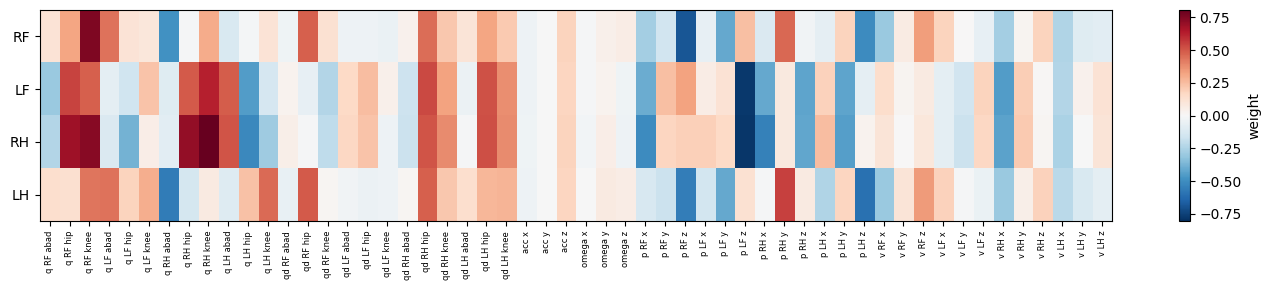

,RF,LF,RH,LH
0,q RF knee (+0.75),p LF z (-0.78),q RH knee (+0.81),p LH z (-0.60)
1,p RF z (-0.69),q RH knee (+0.63),p LF z (-0.78),q RH abad (-0.56)
2,p LH z (-0.50),q RF hip (+0.54),q RF knee (+0.73),p RF z (-0.56)
3,q RH abad (-0.49),qd RH hip (+0.53),q RH hip (+0.71),p RH y (+0.55)
4,qd RF hip (+0.48),qd LH hip (+0.52),q RF hip (+0.68),qd RF hip (+0.49)


In [108]:
W = joblib.load("../outputs/models/ridge_current.joblib")[-1].coef_
fig, ax = plt.subplots(figsize=(14, 3))
im = ax.imshow(W, aspect="auto", cmap="RdBu_r", vmin=-np.abs(W).max(), vmax=np.abs(W).max())
ax.set_yticks(range(4), LEGS); ax.set_xticks(range(54), CHANNELS, rotation=90, fontsize=6)
plt.colorbar(im, ax=ax, label="weight"); plt.tight_layout(); plt.show()
pd.DataFrame({leg: [f"{CHANNELS[j]} ({W[k, j]:+.2f})" for j in np.argsort(-np.abs(W[k]))[:5]]
              for k, leg in enumerate(LEGS)})

Each leg relies on its own **foot height** and **knee angle** — and on the foot height of its
**trot partner** (RF uses LH, RH uses LF): the leg coupling is used through the inputs.
Foot velocities barely appear: "velocity near zero" is not expressible linearly.

Caveat: many channels are strongly correlated (knee angle ↔ foot height through the leg kinematics), so
individual weights can trade off against each other — read the pattern, not single values.

### 4.3 Ridge — raw window (`window_log`, 810 inputs)

Same model; input = the 54 channels at 15 log-spaced lags over the last 150 ms (chosen in section 2.1).

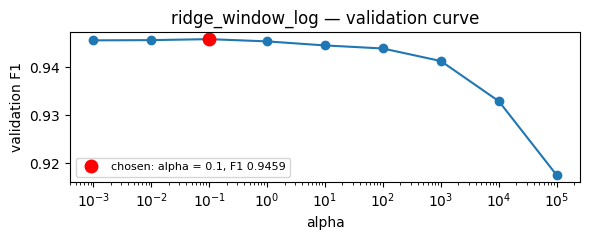

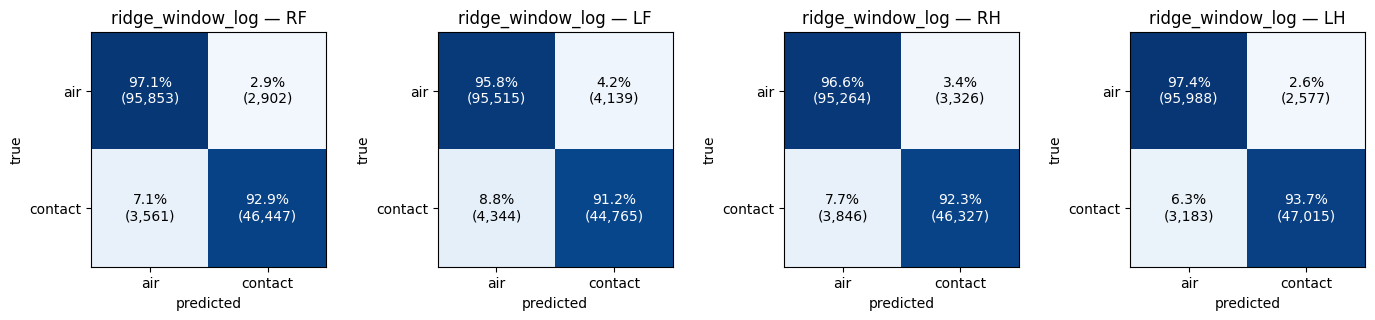

,f1,precision,recall,accuracy
RF,0.9350,0.9412,0.9288,0.9566
LF,0.9135,0.9154,0.9115,0.9430
RH,0.9282,0.9330,0.9233,0.9518
LH,0.9423,0.9480,0.9366,0.9613
mean,0.9297,0.9344,0.9251,0.9532


exact-state accuracy (all 4 legs right): 0.8789


In [109]:
model_card("ridge_window_log")

- α flat again (best 0.1): still under-fitting, now with 810 weights.
- Precision and recall balanced (0.93 / 0.93); LF the hardest leg (0.914).

#### Where in time does it look? Weight magnitude per lag

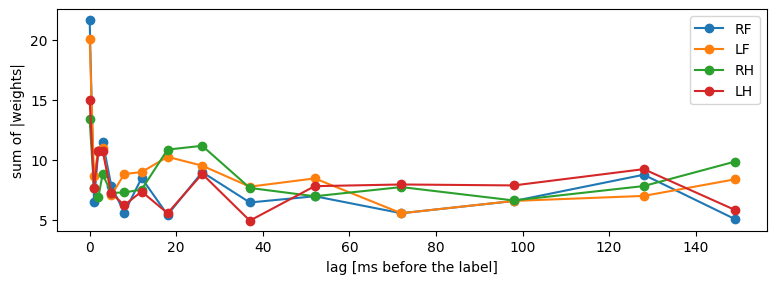

In [110]:
W = joblib.load("../outputs/models/ridge_window_log.joblib")[-1].coef_      # (4 legs, 15 lags x 54 channels)
lags = np.sort(LAGS["window_log"])[::-1]                                     # input order: oldest first
per_lag = np.abs(W.reshape(4, len(lags), 54)).sum(2)                         # summed |weight| per lag
plt.figure(figsize=(8, 3))
for k, leg in enumerate(LEGS):
    plt.plot(lags, per_lag[k], "o-", label=leg)
plt.xlabel("lag [ms before the label]"); plt.ylabel("sum of |weights|"); plt.legend(); plt.tight_layout()

The current timestep (lag 0) carries the most weight, but **every lag up to 149 ms is used** — the model
does look at the whole 150 ms. Read with care: neighbouring lags are near-copies (repeated samples), so large
weights of opposite sign on lags 0–3 largely cancel — that is how a linear model builds **differences**
(velocity/acceleration of a signal) out of raw past values. This is one way history helps a linear model:
it can compute derivatives and short-term trends that a single timestep does not contain.

### 4.4 Ridge — hand-crafted features (`feat_all`, 390 inputs)

Same model; input = the feature groups g1 + g2 (chosen in section 2.2).

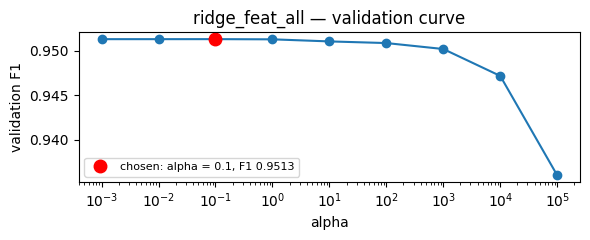

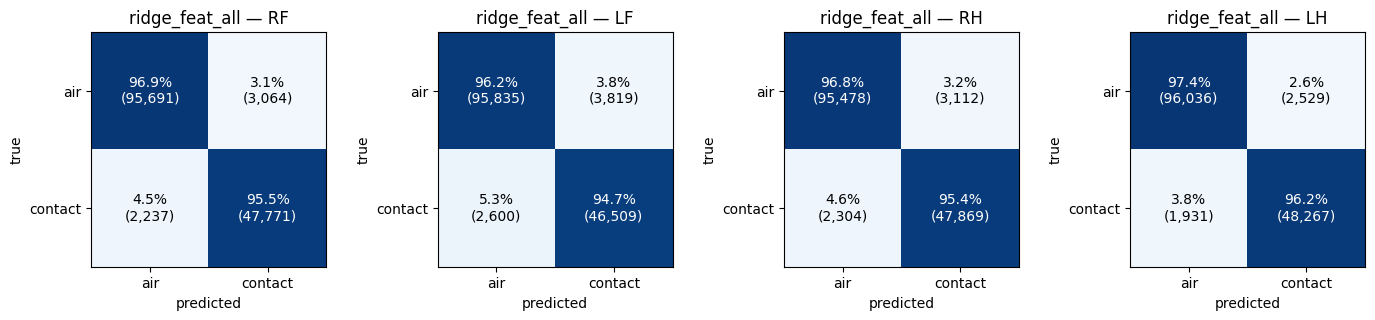

,f1,precision,recall,accuracy
RF,0.9474,0.9397,0.9553,0.9644
LF,0.9354,0.9241,0.9471,0.9569
RH,0.9465,0.9390,0.9541,0.9636
LH,0.9558,0.9502,0.9615,0.9700
mean,0.9463,0.9383,0.9545,0.9637


exact-state accuracy (all 4 legs right): 0.8987


In [111]:
model_card("ridge_feat_all")

- α flat again (best 0.1).
- Recall (0.955) > precision (0.938) because recall rose, not because false contacts increased (section 2.3).
- LF still the hardest leg (0.935); galloping (0.83) the hardest recording.

#### Which feature groups does it use? |weight| per group

In [112]:
W = joblib.load("../outputs/models/ridge_feat_all.joblib")[-1].coef_      # (4, 390), standardized features
groups = {"current": 54, "change 5 ms": 54, "change 50 ms": 54, "mean": 54,
          "std": 54, "min": 54, "max": 54, "foot height − min": 4, "foot speed": 4, "foot speed 20 ms": 4}
bounds = np.cumsum([0] + list(groups.values()))
per_group = pd.DataFrame({leg: [np.abs(W[k, a:b]).sum() for a, b in zip(bounds[:-1], bounds[1:])]
                          for k, leg in enumerate(LEGS)}, index=list(groups))
per_value = per_group.div(list(groups.values()), axis=0)
pd.concat({"sum |w|": per_group.mean(1), "mean |w| per value": per_value.mean(1)}, axis=1).round(2)

,sum |w|,mean |w| per value
current,13.94,0.26
change 5 ms,1.73,0.03
change 50 ms,9.27,0.17
mean,10.36,0.19
std,3.32,0.06
min,4.21,0.08
max,4.76,0.09
foot height − min,0.99,0.25
foot speed,0.21,0.05
foot speed 20 ms,0.16,0.04


Per value, the heaviest weights are on the **current value** (0.26) and **foot height above its window
minimum** (0.25) — the feature that mirrors how the labels were made — then the window mean and the 50 ms change.
The 5 ms change and the foot speeds get small weights, even though removing the foot features costs ~0.2 points
on validation.

Read with care: features of the same channel (current, mean, min, max, changes) are strongly correlated, so
weight can shift between them, and a small weight does not mean a useless feature. The validation ablation
(section 2.2) is the reliable measure of importance; weights only show the pattern.

### 4.5 Ridge on 10k windows (`ridge_10k`, `feat_all`)

The ridge of 4.4, trained on the kernel methods' 10k windows (evenly spaced in time) — the fair reference for them.

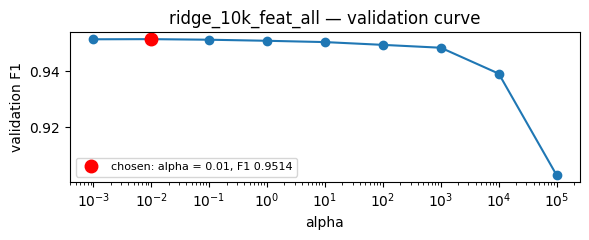

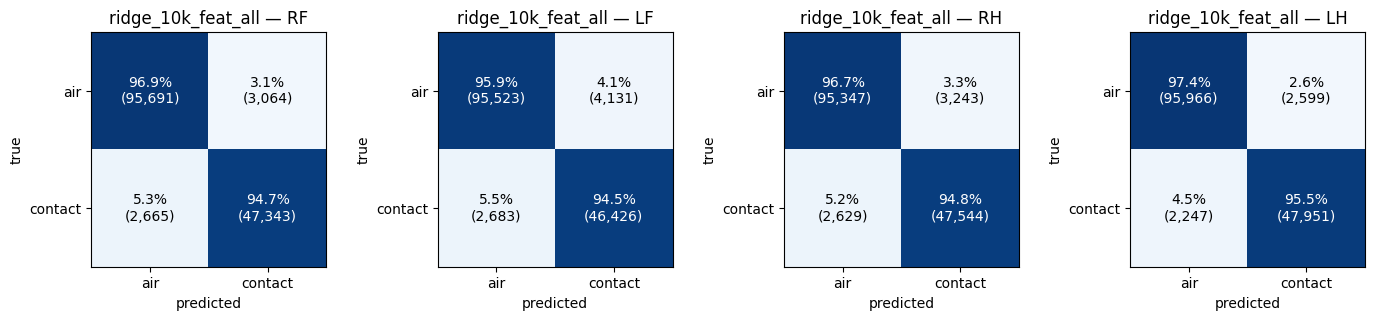

,f1,precision,recall,accuracy
RF,0.9429,0.9392,0.9467,0.9615
LF,0.9316,0.9183,0.9454,0.9542
RH,0.9418,0.9361,0.9476,0.9605
LH,0.9519,0.9486,0.9552,0.9674
mean,0.9421,0.9356,0.9487,0.9609


exact-state accuracy (all 4 legs right): 0.8905


In [113]:
model_card("ridge_10k_feat_all")

- Validation identical to the 70k ridge (0.9514 vs 0.9513), test 0.4 points lower (0.942 vs 0.946): the subsample
  costs a linear model little.
- α again flat up to ~100.

### 4.6 Kernel ridge, RBF (`krr`, `feat_all`)

Standardized features → kernel ridge with RBF kernel k(x, x′) = exp(−γ‖x − x′‖²) on targets ±1 (one output per
leg), contact if the output > 0 — the same loss and penalty as ridge, non-linear boundary. sklearn's `KernelRidge`
has no bias term: the mean target is subtracted before fitting and added back at prediction, which gives it one
(like ridge's intercept). γ = s / 390 (s = 1 is sklearn's default). Trained on the 10k windows of 4.5.
Grid: α ∈ {0.01, 0.03, 0.1, 0.3, 1} × s ∈ {0.1, 0.2, 0.3, 0.5, 1, 2, 3} (35 combinations, ~15 min on a PC).

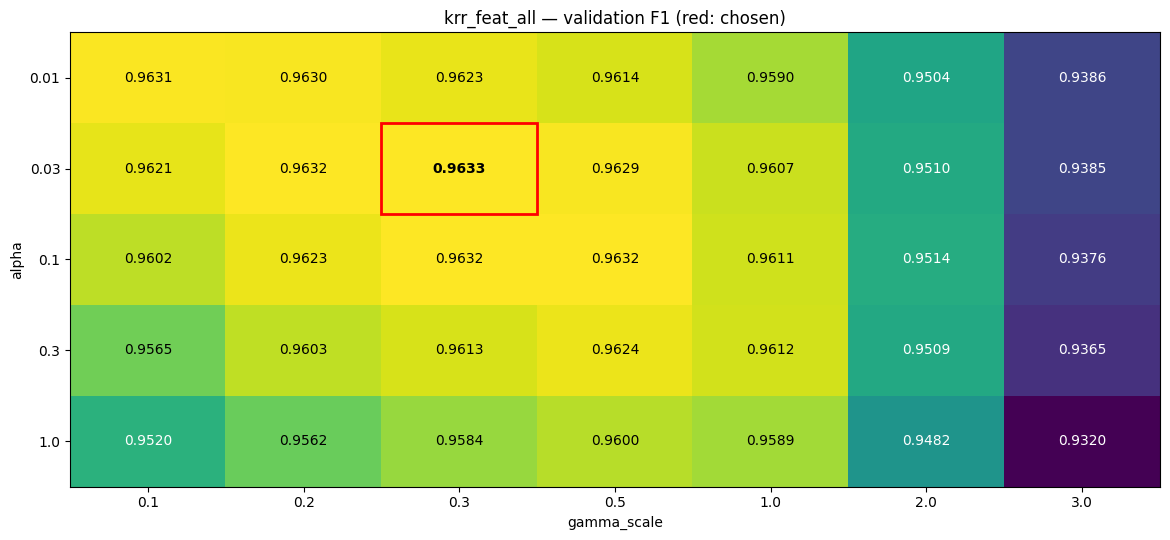

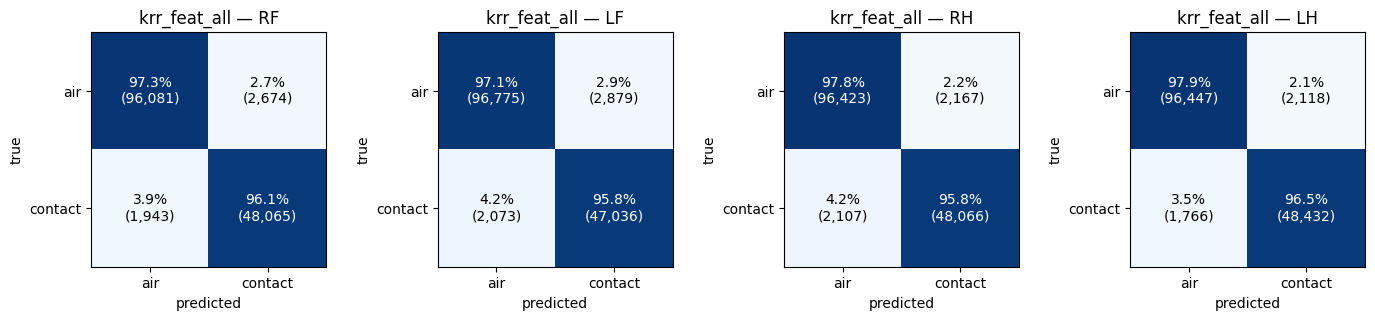

,f1,precision,recall,accuracy
RF,0.9542,0.9473,0.9611,0.9690
LF,0.9500,0.9423,0.9578,0.9667
RH,0.9574,0.9569,0.9580,0.9713
LH,0.9614,0.9581,0.9648,0.9739
mean,0.9558,0.9511,0.9604,0.9702


exact-state accuracy (all 4 legs right): 0.9091


In [114]:
model_card("krr_feat_all")

- **Flat optimum along a diagonal band**: a smaller α (less regularization) pairs with a smaller γ (smoother
  kernel). About ten combinations score within 0.001 of the best (0.9633 at α = 0.03, s = 0.3, inside the grid).
- **Performance does not hinge on tuning.** On a flat plateau, which point wins on validation is mostly chance
  (the "winner's curse" of selection), so validation differences below ~0.1 point are not real differences.
- **Large γ is clearly worse** (s ≥ 2 at every α): the kernel becomes too local (each training window only "sees"
  its very near neighbours) — with 10k windows in 390 dimensions it no longer generalizes.
- α and γ **interact**, as in the EMG project — they have to be searched together, not one at a time.
- Precision 0.951 / recall 0.960; LF still the hardest leg (0.950), but the gap to the other legs is smaller.